# Preprocessing & Feature Extraction Pipeline

This notebook transforms raw Apple Watch sensor CSV files into a clean, labeled feature matrix suitable for training an activity recognition classifier.

**Pipeline overview:**
1. Load raw CSVs and split on recording gaps
2. Resample to a uniform 50 Hz grid
3. Apply a low-pass Butterworth filter to remove high-frequency noise
4. Compute derived signals (acceleration magnitude, jerk, rotation magnitude)
5. Z-score normalize per recording session
6. Segment into fixed-length sliding windows
7. Extract time-domain, frequency-domain, and statistical features via TSFEL
8. Export the resulting feature matrix for model training

Re-run this notebook after adding new `exercise_data_*.csv` files to regenerate the feature set.

In [40]:
import glob, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, interpolate
from sklearn.preprocessing import StandardScaler
import tsfel

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

# ── Label definitions ─────────────────────────────────────────────────────────
LABEL_MAP = {0: "rest", 1: "pull-ups", 2: "bicep-curls",
             3: "lateral-raises", 4: "cardio", 5: "squats"}

# ── Sensor columns used throughout the pipeline ───────────────────────────────
TIME_COL   = "motionTimestamp_sinceReboot(s)"
ACCEL_COLS = ["motionUserAccelerationX(G)",
              "motionUserAccelerationY(G)",
              "motionUserAccelerationZ(G)"]
GYRO_COLS  = ["motionRotationRateX(rad/s)",
              "motionRotationRateY(rad/s)",
              "motionRotationRateZ(rad/s)"]
IMU_COLS   = ACCEL_COLS + GYRO_COLS   # 6 raw channels

# ── Pipeline hyperparameters ──────────────────────────────────────────────────
FS            = 50          # target sampling rate (Hz)
DT            = 1.0 / FS    # target sample interval (s)
GAP_THRESHOLD = 0.5         # recording gap threshold (s); splits continuous segments
FILTER_ORDER  = 3           # Butterworth filter order
FILTER_CUTOFF = 20.0        # low-pass cutoff frequency (Hz)
WINDOW_SEC    = 3.0         # window length (s)
WINDOW_SAMP   = int(WINDOW_SEC * FS)   # 150 samples
STRIDE_SAMP   = WINDOW_SAMP // 2       # 75 samples → 50 % overlap
MIN_LABEL_FRAC = 0.6        # min fraction of a window that must share one label

print("Configuration loaded.")
print(f"  Window: {WINDOW_SEC}s = {WINDOW_SAMP} samples | Stride: {STRIDE_SAMP} samples (50 % overlap)")
print(f"  Butterworth: order {FILTER_ORDER}, cutoff {FILTER_CUTOFF} Hz, fs {FS} Hz")

Configuration loaded.
  Window: 3.0s = 150 samples | Stride: 75 samples (50 % overlap)
  Butterworth: order 3, cutoff 20.0 Hz, fs 50 Hz


---
## Step 1 — Load Raw Data & Split on Recording Gaps

### Why gap-splitting is necessary

The SensorLog app records continuously until manually stopped, but examination of the data (see `data_inspection.ipynb`) revealed **max inter-sample gaps of 85–297 seconds** across the four session files. These gaps occur when the app is paused and resumed mid-workout, creating a single CSV file that is actually composed of multiple discontinuous recording bursts.

If left unsplit, these gaps would produce two concrete problems:

1. **Invalid windows at the boundary.** A 3-second window that straddles a gap would contain, say, 2 seconds of real data from one bout and 1 second from a completely different point in time — the resulting features would be meaningless.
2. **Corrupted resampling and filtering.** Both the uniform-grid interpolation and the Butterworth filter assume that samples are temporally adjacent. A timestamp jump of minutes would cause the interpolator to extrapolate wildly and the filter to ring.

**Splitting criterion:** any consecutive pair of samples whose timestamp difference exceeds `GAP_THRESHOLD = 0.5 s` (25× the nominal 20 ms interval) is treated as a segment boundary. Each resulting segment is then processed as an independent continuous signal.

In [41]:
def load_and_split(csv_path, gap_threshold=GAP_THRESHOLD):
    """
    Load one CSV file and return a list of contiguous segment DataFrames.
    Each segment is a continuous recording burst with no internal gaps.
    """
    df = pd.read_csv(csv_path)
    df = df.sort_values(TIME_COL).reset_index(drop=True)

    # Identify gap boundaries
    dt = df[TIME_COL].diff()
    gap_starts = df.index[dt > gap_threshold].tolist()
    boundaries = [0] + gap_starts + [len(df)]

    segments = []
    for start, end in zip(boundaries[:-1], boundaries[1:]):
        seg = df.iloc[start:end].copy().reset_index(drop=True)
        if len(seg) >= WINDOW_SAMP:   # discard segments shorter than one window
            seg["source_file"] = os.path.basename(csv_path)
            segments.append(seg)

    return segments


# Load all files
csv_files = sorted(glob.glob(os.path.join("data", "exercise_data_*.csv")))
all_segments = []
for fp in csv_files:
    segs = load_and_split(fp)
    all_segments.extend(segs)
    print(f"{os.path.basename(fp)}: {len(segs)} segments")

print(f"\nTotal segments: {len(all_segments)}")
print(f"Segment lengths (samples): "
      f"min={min(len(s) for s in all_segments)}, "
      f"max={max(len(s) for s in all_segments)}, "
      f"mean={np.mean([len(s) for s in all_segments]):.0f}")

exercise_data_0.csv: 2 segments
exercise_data_1.csv: 1 segments
exercise_data_2.csv: 1 segments
exercise_data_3.csv: 1 segments

Total segments: 5
Segment lengths (samples): min=2190, max=93569, mean=44402


---
## Step 2 — Resample to a Uniform 50 Hz Grid

### Why resampling is necessary

The Apple Watch does not guarantee perfectly uniform sample timing — timestamp jitter of ±1–2 ms is normal, and occasional missed samples can create isolated larger gaps. While the median inter-sample interval is very close to the target 20 ms (50 Hz), the raw timestamps are **irregularly spaced**.

Most signal processing algorithms — including the Butterworth filter (which assumes a fixed sample period when computing filter coefficients), TSFEL's frequency-domain features (which use the FFT and require uniform spacing to correctly interpret frequency bins), and any sliding-window scheme that counts samples — implicitly assume a **uniform time axis**. Resampling removes this assumption by:

1. Constructing a perfectly uniform time grid at 50 Hz spanning each segment.
2. Interpolating every sensor channel from the irregular raw grid onto the uniform grid using **cubic spline interpolation**, which provides smooth, continuous estimates between samples and minimizes interpolation artefacts compared to linear interpolation.

For the integer `label` column, **nearest-neighbor interpolation** is used instead, preserving the discrete label values exactly (cubic interpolation would produce nonsensical fractional labels).

In [42]:
def resample_segment(seg, fs=FS):
    """
    Interpolate a segment onto a uniform time grid at `fs` Hz.
    Continuous channels: cubic spline; label: nearest-neighbour.
    Duplicate timestamps are dropped (keep first) before interpolation.
    """
    # Drop duplicate timestamps — CubicSpline requires strictly increasing x
    seg = seg.drop_duplicates(subset=TIME_COL, keep="first")
    seg = seg.sort_values(TIME_COL).reset_index(drop=True)

    t_raw  = seg[TIME_COL].values
    t_grid = np.arange(t_raw[0], t_raw[-1], 1.0 / fs)

    if len(t_grid) < 4:   # not enough points for cubic spline
        return None

    result = {TIME_COL: t_grid,
              "source_file": seg["source_file"].iloc[0]}

    # Continuous sensor channels — cubic spline
    for col in IMU_COLS:
        f = interpolate.CubicSpline(t_raw, seg[col].values, extrapolate=False)
        result[col] = f(t_grid)

    # Integer label — nearest neighbour
    f_label = interpolate.interp1d(t_raw, seg["label"].values,
                                   kind="nearest", fill_value="extrapolate")
    result["label"] = f_label(t_grid).astype(int)

    return pd.DataFrame(result)


resampled_segments = []
for s in all_segments:
    r = resample_segment(s)
    if r is not None and len(r) >= WINDOW_SAMP:
        resampled_segments.append(r)

# Sanity check
sample_dt = np.diff(resampled_segments[0][TIME_COL].values)
print(f"After resampling — mean dt: {sample_dt.mean()*1000:.3f} ms  "
      f"std: {sample_dt.std()*1000:.4f} ms  (target: {1000/FS:.1f} ms)")
print(f"Total resampled samples across all segments: "
      f"{sum(len(s) for s in resampled_segments):,}")

After resampling — mean dt: 20.000 ms  std: 0.0000 ms  (target: 20.0 ms)
Total resampled samples across all segments: 185,298


---
## Step 3 — Low-Pass Butterworth Filter

### Why filter, and why Butterworth?

Raw inertial sensor signals contain noise from multiple sources: electronic sensor noise, micro-vibrations, and quantisation artefacts — all of which manifest as **high-frequency content** well above the frequencies of human voluntary movement. If this high-frequency noise is retained, it contaminates spectral features and inflates variance-based features, making the classifier's job harder.

**Choice of filter type — Butterworth over alternatives:**

A filter can be designed with different trade-offs between its passband flatness, stopband attenuation, and transition steepness. The two most common alternatives to Butterworth in biomechanics are:

| Filter | Passband | Transition | Common use |
|--------|----------|------------|------------|
| **Butterworth** | Maximally flat (no ripple) | Moderate roll-off | Biomechanics, IMU signals |
| Chebyshev Type I | Ripple in passband | Steeper roll-off | When sharp cutoff is critical |
| Chebyshev Type II | Ripple in stopband | Steeper roll-off | When passband flatness matters more |
| Elliptic | Ripple in both | Steepest roll-off | Narrowband applications |

The **Butterworth filter** is the standard choice in human activity recognition and biomechanical signal processing because: (1) its **maximally flat magnitude response** in the passband does not distort the amplitudes of exercise motion frequencies we wish to preserve, and (2) it has no passband ripple, which means feature values computed on filtered data reliably reflect true signal amplitude. Studies such as Winter (2009) and the majority of IMU-based HAR literature (e.g. Reyes-Ortiz et al., 2016; Banos et al., 2014) employ a Butterworth low-pass filter for exactly these reasons.

**Filter order (N = 3):** Higher order means a steeper roll-off (more aggressive rejection of frequencies above the cutoff) but also more phase distortion and potential ringing artefacts. A 3rd-order filter provides a good balance — sufficient attenuation of noise above 20 Hz while keeping phase distortion manageable. To **eliminate all phase distortion**, `sosfiltfilt` is used, which applies the filter twice (forward and backward), resulting in a zero-phase response at the cost of doubling the effective filter order (net effective order = 6).

**Cutoff frequency (20 Hz):** Human voluntary limb movements during exercise (pull-ups, curls, squats, cardio walking/running) are well-contained below 10 Hz. The Apple Watch samples at 50 Hz, giving a Nyquist frequency of 25 Hz. A 20 Hz cutoff removes sensor noise in the 20–25 Hz band while preserving all biomechanically relevant motion frequencies with a comfortable margin.

In [43]:
# Design the filter once and reuse it for all segments/channels.
# Using second-order sections (sos) representation for improved numerical
# stability compared to the traditional (b, a) transfer-function form.
sos = signal.butter(FILTER_ORDER, FILTER_CUTOFF, btype="low",
                    fs=FS, output="sos")

def apply_filter(seg):
    """Apply zero-phase Butterworth low-pass filter to all IMU channels."""
    seg = seg.copy()
    for col in IMU_COLS:
        seg[col] = signal.sosfiltfilt(sos, seg[col].values)
    return seg

filtered_segments = [apply_filter(s) for s in resampled_segments]
print(f"Filtered {len(filtered_segments)} segments.")

Filtered 5 segments.


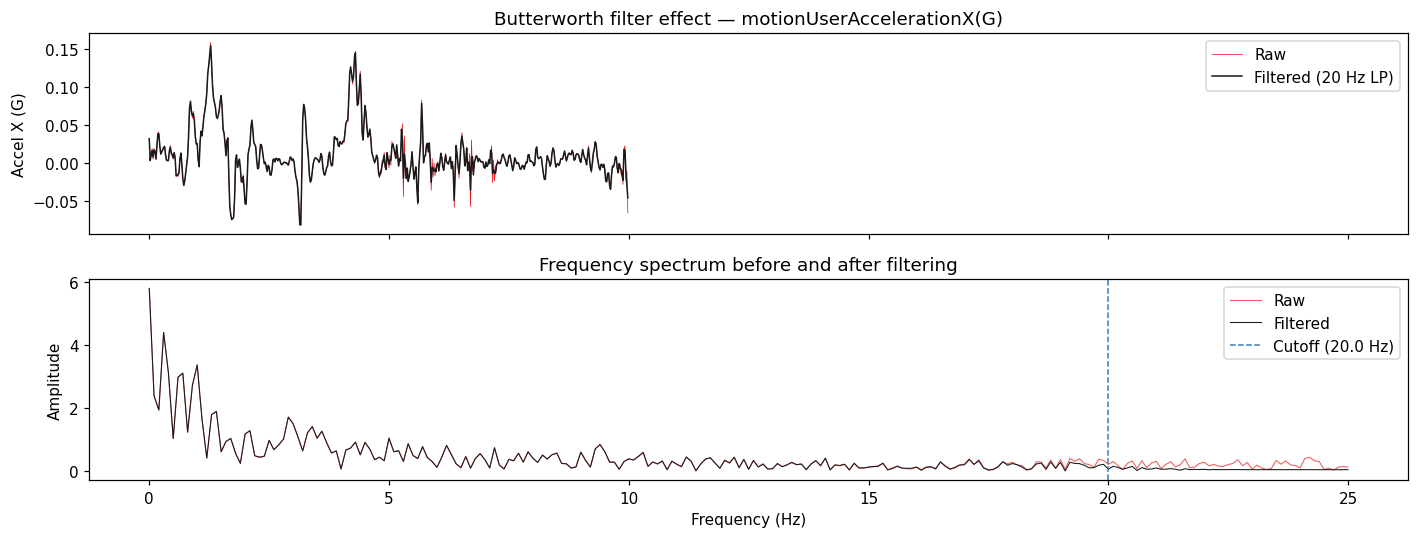

In [44]:
# ── Visualise filter effect on a representative exercise segment ──────────────
# Find a segment that contains at least one non-rest label
ex_seg_raw = next(s for s in resampled_segments
                  if (s["label"] != 0).any())
ex_seg_filt = filtered_segments[resampled_segments.index(ex_seg_raw)]

# Show first 10 seconds
n_show = min(500, len(ex_seg_raw))
t = ex_seg_raw[TIME_COL].values[:n_show] - ex_seg_raw[TIME_COL].values[0]

col = ACCEL_COLS[0]   # X-axis user acceleration
fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)

axes[0].plot(t, ex_seg_raw[col].values[:n_show],
             linewidth=0.5, color="#e41a1c", label="Raw")
axes[0].plot(t, ex_seg_filt[col].values[:n_show],
             linewidth=1.0, color="#1a1a1a", label="Filtered (20 Hz LP)")
axes[0].set_ylabel("Accel X (G)")
axes[0].set_title(f"Butterworth filter effect — {col}")
axes[0].legend()

# Frequency content before / after
freqs = np.fft.rfftfreq(n_show, d=1/FS)
raw_fft  = np.abs(np.fft.rfft(ex_seg_raw[col].values[:n_show]))
filt_fft = np.abs(np.fft.rfft(ex_seg_filt[col].values[:n_show]))
axes[1].plot(freqs, raw_fft,  linewidth=0.7, color="#e41a1c", label="Raw",     alpha=0.7)
axes[1].plot(freqs, filt_fft, linewidth=0.7, color="#1a1a1a", label="Filtered")
axes[1].axvline(FILTER_CUTOFF, color="#377eb8", linestyle="--",
                linewidth=1, label=f"Cutoff ({FILTER_CUTOFF} Hz)")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Frequency spectrum before and after filtering")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Step 4 — Derived Signals

### Motivation

The six raw IMU channels (3-axis accelerometer, 3-axis gyroscope) describe motion along individual axes of the watch's local coordinate frame. However, the orientation of the watch on the wrist varies between sessions and even between sets within a session. **Derived magnitude signals are rotation-invariant** — they describe the overall intensity of movement regardless of how the watch is oriented — making them particularly informative for distinguishing activity classes.

Three derived signals are computed:

| Signal | Formula | Physical meaning |
|--------|---------|-----------------|
| **`accel_mag`** | $\|\mathbf{a}\| = \sqrt{a_x^2 + a_y^2 + a_z^2}$ | Overall linear acceleration intensity (gravity-removed) |
| **`gyro_mag`** | $\|\boldsymbol{\omega}\| = \sqrt{\omega_x^2 + \omega_y^2 + \omega_z^2}$ | Overall angular velocity (rotational intensity) |
| **`jerk_mag`** | $\frac{d\|\mathbf{a}\|}{dt}$ (finite difference) | Rate of change of acceleration — captures the impulsive, sharp motion changes characteristic of repetitive exercises like pull-ups and lateral raises |

Jerk is particularly discriminative for repetitive weightlifting exercises because each repetition produces a characteristic acceleration burst followed by a rapid deceleration. The temporal pattern of jerk peaks encodes both cadence (repetition rate) and motion sharpness, which differ substantially across exercise types.

In [45]:
def add_derived_signals(seg):
    """Compute rotation-invariant magnitude signals and jerk."""
    seg = seg.copy()

    seg["accel_mag"] = np.sqrt(
        seg["motionUserAccelerationX(G)"]**2 +
        seg["motionUserAccelerationY(G)"]**2 +
        seg["motionUserAccelerationZ(G)"]**2
    )
    seg["gyro_mag"] = np.sqrt(
        seg["motionRotationRateX(rad/s)"]**2 +
        seg["motionRotationRateY(rad/s)"]**2 +
        seg["motionRotationRateZ(rad/s)"]**2
    )
    # Finite-difference jerk; first sample duplicated to keep length constant
    jerk = np.diff(seg["accel_mag"].values, prepend=seg["accel_mag"].values[0])
    seg["jerk_mag"] = jerk * FS   # units: G/s

    return seg

derived_segments = [add_derived_signals(s) for s in filtered_segments]

# All channels that will be used in feature extraction
DERIVED_COLS   = ["accel_mag", "gyro_mag", "jerk_mag"]
FEATURE_COLS   = IMU_COLS + DERIVED_COLS   # 9 channels total

print(f"Feature channels ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Feature channels (9): ['motionUserAccelerationX(G)', 'motionUserAccelerationY(G)', 'motionUserAccelerationZ(G)', 'motionRotationRateX(rad/s)', 'motionRotationRateY(rad/s)', 'motionRotationRateZ(rad/s)', 'accel_mag', 'gyro_mag', 'jerk_mag']


---
## Step 5 — Z-Score Normalization (Per Session)

### Why normalize, and why per session?

Sensor readings from a wearable device are affected by factors external to the activity being performed: wrist position, watch fit tightness, arm length, and individual biomechanics all shift the absolute magnitude of recorded signals. A classifier trained on raw amplitude values may learn to discriminate *sessions* rather than *activities* — overfitting to inter-session variation rather than generalising to the underlying motion patterns.

**Z-score normalization** (standardisation to zero mean and unit variance) removes the session-level DC offset and scale from each channel, so the model sees **relative** signal dynamics rather than absolute amplitudes.

**Why per session (source file) and not globally?**

Global normalization would compute a single mean and standard deviation across all sessions combined. The risk is that one unusually active or unusually quiet session could dominate the global statistics, compressing the dynamic range of other sessions. Per-session normalization is the standard approach in wearable HAR literature (e.g., Anguita et al., 2013; Kwapisz et al., 2011) because it makes the representation **session-invariant**: signals from a 5-minute session and a 30-minute session are treated on the same footing.

The scaler is fit on the data within each source file (all segments belonging to that file) and then applied to those same segments — equivalent to per-session zero-mean unit-variance scaling. No data from other sessions leaks into the normalization of a given session, which is important for the integrity of leave-one-session-out cross-validation used later during model evaluation.

In [46]:
# Group segments by source file and fit one scaler per session
session_scalers = {}
for src_file in set(s["source_file"].iloc[0] for s in derived_segments):
    session_data = pd.concat(
        [s[FEATURE_COLS] for s in derived_segments
         if s["source_file"].iloc[0] == src_file],
        ignore_index=True,
    )
    scaler = StandardScaler()
    scaler.fit(session_data)
    session_scalers[src_file] = scaler

def normalize_segment(seg):
    """Apply the per-session z-score scaler to a segment's feature columns."""
    seg = seg.copy()
    src = seg["source_file"].iloc[0]
    seg[FEATURE_COLS] = session_scalers[src].transform(seg[FEATURE_COLS])
    return seg

normalized_segments = [normalize_segment(s) for s in derived_segments]

# Verify: check mean and std of one session's segments after normalization
src_check = normalized_segments[0]["source_file"].iloc[0]
combined = pd.concat(
    [s[FEATURE_COLS] for s in normalized_segments
     if s["source_file"].iloc[0] == src_check],
    ignore_index=True,
)
print(f"Post-normalization check for '{src_check}':")
print(f"  Mean (should be ~0): {combined.mean().round(4).to_dict()}")
print(f"  Std  (should be ~1): {combined.std().round(4).to_dict()}")

Post-normalization check for 'exercise_data_0.csv':
  Mean (should be ~0): {'motionUserAccelerationX(G)': -0.0, 'motionUserAccelerationY(G)': 0.0, 'motionUserAccelerationZ(G)': -0.0, 'motionRotationRateX(rad/s)': 0.0, 'motionRotationRateY(rad/s)': 0.0, 'motionRotationRateZ(rad/s)': -0.0, 'accel_mag': -0.0, 'gyro_mag': -0.0, 'jerk_mag': 0.0}
  Std  (should be ~1): {'motionUserAccelerationX(G)': 1.0, 'motionUserAccelerationY(G)': 1.0, 'motionUserAccelerationZ(G)': 1.0, 'motionRotationRateX(rad/s)': 1.0, 'motionRotationRateY(rad/s)': 1.0, 'motionRotationRateZ(rad/s)': 1.0, 'accel_mag': 1.0, 'gyro_mag': 1.0, 'jerk_mag': 1.0}


---
## Step 6 — Sliding Window Segmentation

### Design choices

**Window length (3 seconds = 150 samples at 50 Hz):**
A window must be long enough to capture at least one full repetition of the slowest exercise. Typical cadences for the activities in this dataset are 0.3–1.0 repetitions per second, meaning a 3-second window will contain 1–3 full repetitions. Windows shorter than 2 seconds risk capturing only a partial repetition, making frequency-domain features unreliable. Windows longer than 4–5 seconds reduce the total window count and may span multiple label transitions, causing ambiguous ground truth. 3 seconds is the consensus window length used in smartphone/smartwatch HAR literature (Anguita et al., 2013; Banos et al., 2014).

**Overlap (50% = stride of 75 samples):**
A 50% overlap between consecutive windows serves two purposes: (1) it **doubles the number of training windows** from a fixed amount of recorded data, which is especially helpful for classes with fewer recorded sets (cardio, squats); and (2) it ensures that the features of any given moment in the signal appear in at least two windows, reducing the risk that a classifier misses a feature because it happened to fall at the boundary between two non-overlapping windows. 50% is the standard overlap used in the majority of HAR work.

**Window labeling — majority vote:**
Because windows may occasionally straddle a label transition (e.g., the last few samples of a rest period and the beginning of a pull-up set), a simple majority-vote rule is applied: the label that accounts for the largest fraction of samples in the window is assigned as the window's ground-truth label. Windows where the majority label accounts for less than `MIN_LABEL_FRAC = 0.6` (60%) of samples are discarded to avoid training on ambiguous transitions.

In [47]:
def extract_windows(seg, seg_idx, window=WINDOW_SAMP, stride=STRIDE_SAMP,
                    min_label_frac=MIN_LABEL_FRAC):
    """
    Slide a window over a segment and return a list of
    (signal_array [window × n_channels], label, source_file, set_id) tuples.
    Windows with ambiguous labels (below min_label_frac) are discarded.
    
    set_id identifies the contiguous label run (exercise "set") that each
    window predominantly belongs to, enabling Leave-One-Set-Out CV.
    """
    data   = seg[FEATURE_COLS].values
    labels = seg["label"].values
    src    = seg["source_file"].iloc[0]

    # Identify contiguous label runs within this segment
    run_ids = pd.Series(labels).ne(pd.Series(labels).shift()).cumsum().values

    windows = []
    for start in range(0, len(seg) - window + 1, stride):
        win_data   = data[start : start + window]
        win_labels = labels[start : start + window]
        win_runs   = run_ids[start : start + window]

        # Majority-vote label
        values, counts = np.unique(win_labels, return_counts=True)
        majority_label = values[np.argmax(counts)]
        majority_frac  = counts.max() / window

        if majority_frac >= min_label_frac:
            # Assign set_id based on the dominant label run in this window
            run_vals, run_cnts = np.unique(win_runs, return_counts=True)
            dominant_run = run_vals[np.argmax(run_cnts)]
            set_id = f"{src}_seg{seg_idx:03d}_run{dominant_run:04d}"
            windows.append((win_data, majority_label, src, set_id))

    return windows


all_windows = []
for seg_idx, seg in enumerate(normalized_segments):
    all_windows.extend(extract_windows(seg, seg_idx))

win_labels  = np.array([w[1] for w in all_windows])
win_sources = np.array([w[2] for w in all_windows])
win_set_ids = np.array([w[3] for w in all_windows])

print(f"Total windows extracted: {len(all_windows):,}")
print(f"Unique sets (for LOSO-Set CV): {len(np.unique(win_set_ids))}")
print(f"\nWindows per class:")
for label_id in sorted(np.unique(win_labels)):
    n = (win_labels == label_id).sum()
    print(f"  {label_id} ({LABEL_MAP[label_id]:>16s}): {n:>4d} windows  "
          f"({n / len(all_windows) * 100:.1f} %)")

Total windows extracted: 2,446
Unique sets (for LOSO-Set CV): 58

Windows per class:
  0 (            rest):  815 windows  (33.3 %)
  1 (        pull-ups):  311 windows  (12.7 %)
  2 (     bicep-curls):  368 windows  (15.0 %)
  3 (  lateral-raises):  340 windows  (13.9 %)
  4 (          cardio):  337 windows  (13.8 %)
  5 (          squats):  275 windows  (11.2 %)


---
## Step 7 — Feature Extraction with TSFEL

### Why handcrafted features rather than raw windows?

Two broad approaches exist for classifying IMU windows: (1) train a deep model (e.g., CNN-LSTM) directly on the raw sample values, or (2) extract a fixed-length handcrafted feature vector from each window and train a classical model (e.g., XGBoost). With ~5,000–6,000 windows total (well below the 10,000+ typically recommended for deep learning), the **handcrafted feature + classical model** approach is more appropriate for this dataset: it is less prone to overfitting, interpretable, and achieves state-of-the-art accuracy on comparable HAR benchmarks (Anguita et al., 2013; Reyes-Ortiz et al., 2016).

### TSFEL — Time Series Feature Extraction Library

TSFEL (Barandas et al., 2020) provides a systematic collection of features organized into four domains. Three are used here; the fractal domain is excluded because its features (Hurst exponent, DFA) are computationally expensive and of limited discriminative value for short 3-second exercise windows.

| Domain | # features/channel | Examples | Why useful for HAR |
|--------|--------------------|---------|-------------------|
| **Temporal** | ~15 | Mean absolute deviation, autocorrelation, zero-crossing rate, peak count | Captures amplitude dynamics and periodicity of repetitive motions |
| **Statistical** | ~20 | Mean, variance, skewness, kurtosis, interquartile range, entropy | Summarises the amplitude distribution; rest vs. exercise separation |
| **Spectral** | ~26 | Dominant frequency, spectral centroid, spectral energy, MFCC | Encodes the frequency signature of each activity; highly discriminative for cadence-based separation |

Features are computed **independently for each of the 9 signal channels** (3-axis accel, 3-axis gyro, accel magnitude, gyro magnitude, jerk magnitude), yielding a total of approximately 9 × 61 ≈ 549 features per window before any selection or dimensionality reduction.

### Reference
Barandas, M., et al. (2020). TSFEL: Time Series Feature Extraction Library. *SoftwareX*, 11, 100456.

In [48]:
# Build TSFEL config: temporal + statistical + spectral only
tsfel_cfg = {
    **tsfel.get_features_by_domain("temporal"),
    **tsfel.get_features_by_domain("statistical"),
    **tsfel.get_features_by_domain("spectral"),
}

# Rename feature cols to short channel names for readable column headers
CHANNEL_NAMES = ["acc_x", "acc_y", "acc_z",
                 "gyr_x", "gyr_y", "gyr_z",
                 "accel_mag", "gyro_mag", "jerk_mag"]

def extract_features_for_window(win_array):
    """
    Run TSFEL on a single window array (WINDOW_SAMP × n_channels).
    Returns a 1-D feature array.
    """
    win_df = pd.DataFrame(win_array, columns=CHANNEL_NAMES)
    feats  = tsfel.time_series_features_extractor(
        tsfel_cfg, win_df, fs=FS, verbose=0
    )
    return feats.values.flatten()

# Extract features — this is the most time-consuming step
print(f"Extracting features from {len(all_windows):,} windows "
      f"({len(CHANNEL_NAMES)} channels × TSFEL temporal+statistical+spectral)...")
print("This may take a few minutes.\n")

feature_rows = []
for i, (win_data, label, src, set_id) in enumerate(all_windows):
    if i % 500 == 0:
        print(f"  {i:>5d} / {len(all_windows)} windows processed...")
    feature_rows.append(extract_features_for_window(win_data))

X_raw = np.array(feature_rows)
print(f"\nFeature matrix shape: {X_raw.shape}  "
      f"({X_raw.shape[0]} windows × {X_raw.shape[1]} features)")

Extracting features from 2,446 windows (9 channels × TSFEL temporal+statistical+spectral)...
This may take a few minutes.

      0 / 2446 windows processed...
    500 / 2446 windows processed...
   1000 / 2446 windows processed...
   1500 / 2446 windows processed...
   2000 / 2446 windows processed...

Feature matrix shape: (2446, 1404)  (2446 windows × 1404 features)


---
## Step 8 — Post-Extraction Cleaning

### Constant and NaN features

TSFEL can occasionally produce `NaN` or constant-valued features for short or low-variance windows (e.g., some spectral features require a minimum signal length or non-zero variance). These features carry no discriminative information and can cause numerical issues in downstream models.

The cleaning procedure:
1. **Drop NaN columns** — any feature column that contains at least one `NaN` across all windows is removed. A `NaN` in even one window would propagate to `NaN` predictions for that window in some models.
2. **Drop near-constant columns** — features whose variance falls below a small threshold (`1e-10`) are constant or near-constant across all windows and provide no information for classification.

In [49]:
# Retrieve feature column names from one example extraction run
sample_win_df = pd.DataFrame(all_windows[0][0], columns=CHANNEL_NAMES)
sample_feats  = tsfel.time_series_features_extractor(
    tsfel_cfg, sample_win_df, fs=FS, verbose=0
)
feature_names = list(sample_feats.columns)

X_df = pd.DataFrame(X_raw, columns=feature_names)

# Drop NaN columns
nan_cols = X_df.columns[X_df.isna().any()].tolist()
X_df = X_df.drop(columns=nan_cols)
print(f"Dropped {len(nan_cols)} NaN feature column(s).")

# Drop near-constant columns
low_var_cols = X_df.columns[X_df.var() < 1e-10].tolist()
X_df = X_df.drop(columns=low_var_cols)
print(f"Dropped {len(low_var_cols)} near-constant feature column(s).")

print(f"\nClean feature matrix: {X_df.shape[0]} windows × {X_df.shape[1]} features")

Dropped 0 NaN feature column(s).
Dropped 134 near-constant feature column(s).

Clean feature matrix: 2446 windows × 1270 features


---
## Step 9 — Export the Feature Dataset

The final dataset is saved as both **Parquet** (efficient binary format, preserves dtypes, fast I/O) and **CSV** (human-readable, importable into any tool). Three additional metadata columns are appended:

- `label` — integer class label (0–5)
- `source_file` — originating CSV filename, used later for cross-validation splits
- `set_id` — unique identifier for each contiguous exercise "set" (label run within a segment), used for Leave-One-Set-Out cross-validation

The dataset is saved to `data/features.parquet` and `data/features.csv`.

In [50]:
X_df["label"]       = win_labels
X_df["source_file"] = win_sources
X_df["set_id"]      = win_set_ids

out_parquet = os.path.join("data", "features.parquet")
out_csv     = os.path.join("data", "features.csv")

X_df.to_parquet(out_parquet, index=False)
X_df.to_csv(out_csv, index=False)

print(f"Saved {len(X_df):,} rows × {X_df.shape[1]} columns")
print(f"  {out_parquet}  ({os.path.getsize(out_parquet)/1024:.0f} KB)")
print(f"  {out_csv}      ({os.path.getsize(out_csv)/1024:.0f} KB)")

print(f"\nClass distribution in exported dataset:")
for label_id in sorted(X_df["label"].unique()):
    n = (X_df["label"] == label_id).sum()
    print(f"  {label_id} ({LABEL_MAP[label_id]:>16s}): {n:>4d} windows")

Saved 2,446 rows × 1273 columns
  data/features.parquet  (27312 KB)
  data/features.csv      (57736 KB)

Class distribution in exported dataset:
  0 (            rest):  815 windows
  1 (        pull-ups):  311 windows
  2 (     bicep-curls):  368 windows
  3 (  lateral-raises):  340 windows
  4 (          cardio):  337 windows
  5 (          squats):  275 windows


---
## Step 10 — Dataset Summary & Sanity Checks

Final visual checks to confirm the feature dataset is coherent before handing it off to the model training notebook.

Windows per session × class:


,rest,pull-ups,bicep-curls,lateral-raises,cardio,squats,total
source_file,,,,,,,
exercise_data_0.csv,109,103,0,0,0,0,212
exercise_data_1.csv,355,88,301,287,0,0,1031
exercise_data_2.csv,5,0,0,0,337,0,342
exercise_data_3.csv,346,120,67,53,0,275,861


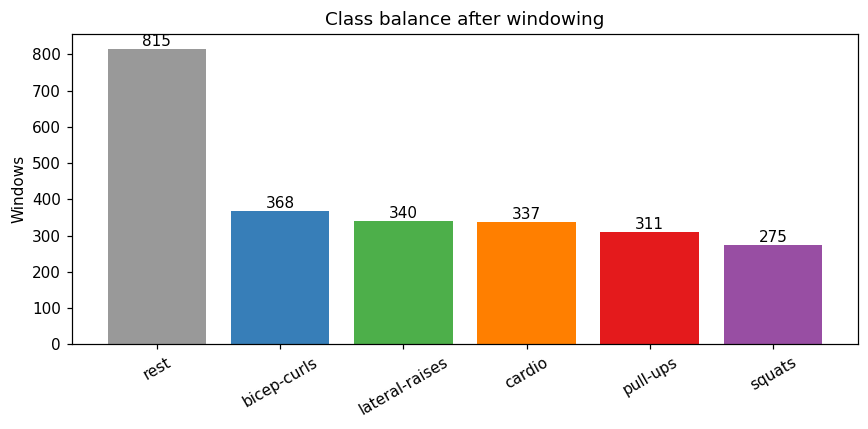

In [51]:
# ── 1. Window count per class × session ──────────────────────────────────────
pivot = X_df.groupby(["source_file", "label"]).size().unstack(fill_value=0)
pivot.columns = [LABEL_MAP[c] for c in pivot.columns]
pivot["total"] = pivot.sum(axis=1)
print("Windows per session × class:")
display(pivot)

# ── 2. Class balance bar chart ────────────────────────────────────────────────
COLORS = {"rest": "#999999", "pull-ups": "#e41a1c", "bicep-curls": "#377eb8",
          "lateral-raises": "#4daf4a", "cardio": "#ff7f00", "squats": "#984ea3"}

counts = X_df["label"].map(LABEL_MAP).value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(counts.index, counts.values,
              color=[COLORS.get(c, "#333") for c in counts.index])
ax.bar_label(bars, fmt="{:.0f}")
ax.set_ylabel("Windows")
ax.set_title("Class balance after windowing")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

NaN values in feature matrix: 0
Inf values in feature matrix: 0
Feature value range: [-46306.826, 29339.309]


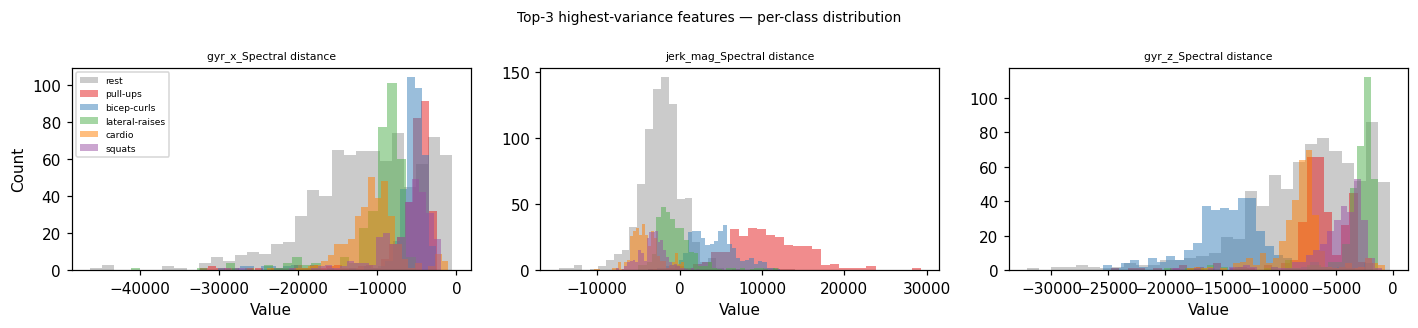


Preprocessing complete. Feature dataset ready for model training.


In [52]:
# ── 3. Feature NaN / Inf audit ────────────────────────────────────────────────
feat_only = X_df.drop(columns=["label", "source_file", "set_id"])
n_nan = feat_only.isna().sum().sum()
n_inf = np.isinf(feat_only.values).sum()
print(f"NaN values in feature matrix: {n_nan}")
print(f"Inf values in feature matrix: {n_inf}")
print(f"Feature value range: [{feat_only.values.min():.3f}, {feat_only.values.max():.3f}]")

# ── 4. Feature distribution spot-check (top 3 highest-variance features) ─────
top_var = feat_only.var().nlargest(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, col in zip(axes, top_var):
    for label_id in sorted(X_df["label"].unique()):
        vals = X_df.loc[X_df["label"] == label_id, col]
        ax.hist(vals, bins=30, alpha=0.5,
                label=LABEL_MAP[label_id],
                color=list(COLORS.values())[label_id])
    ax.set_title(col[:45], fontsize=7)
    ax.set_xlabel("Value")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=6)
plt.suptitle("Top-3 highest-variance features — per-class distribution", fontsize=9)
plt.tight_layout()
plt.show()

print("\nPreprocessing complete. Feature dataset ready for model training.")